In [1]:
import pandas as pd

df = pd.read_csv(
    "../punjab_master_dataset_expanded_cleaned.csv"
)

df.head()

,district,year,season,crop,area_hectares,production_tonnes,yield_kg_per_ha,soil_type,ph,nitrogen_kg_per_ha,...,annual_recharge_mcm,annual_extraction_mcm,extraction_percent,future_groundwater_availability_mcm,water_stress_index,temp_range,rainfall_category,water_stress_category,fertility_score,climate_stress_score
0,Amritsar,2016,Kharif,Cotton,22020.8,37497.0,1702.8,Alluvial,7.14,156.1,...,1099.6,973.4,88.5,126.2,0.89,10.8,High,High,111.6,10.54
1,Amritsar,2016,Kharif,Cotton,20808.6,47812.5,2297.7,Alluvial,7.14,155.9,...,1099.6,973.4,88.5,126.2,0.91,10.8,High,High,111.5,10.65
2,Amritsar,2016,Kharif,Cotton,24497.9,25070.2,1023.4,Alluvial,7.14,156.5,...,1099.6,973.4,88.5,126.2,0.90,9.3,High,High,112.4,10.75
3,Amritsar,2016,Kharif,Cotton,21486.4,28307.7,1317.5,Alluvial,7.14,156.9,...,1099.6,973.4,88.5,126.2,0.90,11.0,High,High,110.2,10.61
4,Amritsar,2016,Kharif,Cotton,23175.1,38645.6,1667.5,Alluvial,7.14,154.8,...,1099.6,973.4,88.5,126.2,0.89,10.5,High,High,112.5,10.52


In [2]:
# import sys

# sys.path.append("../backend")

# from app.services.qssm_service import compute_qssm

import sys
import os

sys.path.append(
    os.path.abspath("../backend")
)

from app.services.qssm_service import compute_qssm

print("Import success ✅")

Import success ✅


In [3]:
print(df.columns.tolist())

['district', 'year', 'season', 'crop', 'area_hectares', 'production_tonnes', 'yield_kg_per_ha', 'soil_type', 'ph', 'nitrogen_kg_per_ha', 'phosphorus_kg_per_ha', 'potassium_kg_per_ha', 'organic_carbon_percent', 'moisture_percent', 'avg_temp', 'max_temp', 'min_temp', 'rainfall', 'humidity', 'wind_speed', 'air_pressure', 'annual_recharge_mcm', 'annual_extraction_mcm', 'extraction_percent', 'future_groundwater_availability_mcm', 'water_stress_index', 'temp_range', 'rainfall_category', 'water_stress_category', 'fertility_score', 'climate_stress_score']


In [4]:
df = compute_qssm(df)

df[
    ["district", "crop", "QSSM_score"]
].head()

,district,crop,QSSM_score
0,Amritsar,Cotton,53.583216
1,Amritsar,Cotton,53.827242
2,Amritsar,Cotton,54.498819
3,Amritsar,Cotton,53.599053
4,Amritsar,Cotton,53.530924


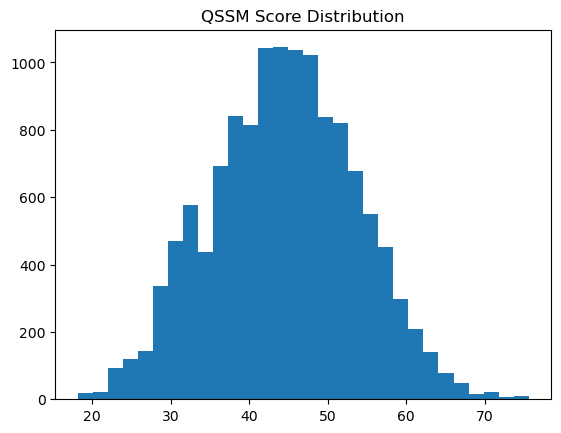

In [5]:
import matplotlib.pyplot as plt

plt.hist(
    df["QSSM_score"],
    bins=30
)

plt.title("QSSM Score Distribution")

plt.show()

In [6]:
df["QSSM_score"].describe()

count    12880.000000
mean        44.440786
std          9.240365
min         18.180402
25%         38.006409
50%         44.503189
75%         50.974592
max         75.569515
Name: QSSM_score, dtype: float64

In [7]:
df.to_csv(

    "../data/processed/"
    "dataset_with_qssm.csv",

    index=False
)

In [9]:
import joblib

joblib.dump(
    compute_qssm,
    "../models/qssm_model/qssm_engine.pkl"
)

['../models/qssm_model/qssm_engine.pkl']